In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using DataFrames, CairoMakie, FHist
using Distributions, Statistics, SpecialFunctions
using JLD2, CSV, LaTeXStrings

In [3]:
include("./utils.jl")
using .Utils

In [4]:
# @load "./Data/processed/microbiome.jld2" MICROBIOME;
# @load "./Data/processed/genetic.jld2" GENETIC;
# @load "./Data/processed/books.jld2" BOOKS;
# @load "./Data/processed/mobility.jld2" MOBILITY;
# @load "./Data/processed/null_model.jld2" NULL_MODEL;

In [5]:
# Utils.df_filter!(MICROBIOME; min_samples=5e1, min_nreads=1e4);

In [6]:
# cutoffs_microbiome = Dict("SLUDGE" => exp(-18.8), "LAKE" => exp(-17.0), "RIVER" => exp(-17.5), "GUT" => exp(-17.5), "GLACIER" => exp(-16.25), "SEAWATER" => exp(-17.9),
#     "SOIL" => exp(-14.25), "ORAL" => exp(-16.1), "VAGINAL" => exp(-Inf), "FECES" => exp(-Inf), "AQUA1" => exp(-17), "AQUA2" => exp(-Inf), "ORALCAVITY" => exp(-14.0), "SKIN" => exp(-Inf));

# cutoffs_genetic = Dict("BRAIN" => exp(-13), "HEART" => exp(-13), "LIVER" => exp(-13), "PANCREAS" => exp(-13));

# cutoffs_books = Dict("ANIMALS" => exp(-17), "GEOGRAPHY" => exp(-17), "CHILDREN" => exp(-17), "ND" => exp(-16), "FICTION" => exp(-16));

# cutoffs_mobility = Dict("CHECK-IN" => exp(-16.0));

In [7]:
# println("AFD")
# out = Utils.compute_AFD(MICROBIOME; occ=1, bins=30, plot=false, verbose=true, save=true, filename="./Data/AFD/microbiome_afd");

# println("TL")
# out = Utils.compute_TL(MICROBIOME; occ=0.9, bins=30, plot=false, verbose=true, save=true, filename="./Data/TL/microbiome_tl", interpretation=2);

# println("MAD")
# out = Utils.compute_MAD(MICROBIOME; c=nothing, bins=30, plot=false, verbose=true, save=true, filename="./Data/MAD/microbiome_mad");

# println("Corrs")
# out = Utils.compute_pearson(MICROBIOME; occ=0.9, bins=30, plot=false, verbose=true, save=true, filename="./Data/Pearson/microbiome_corr_9",
#     interpretation = 2);

# Big figure

In [8]:
### Import distributions ###
# AFD
@load "./Data/AFD/microbiome_afd.jld2" afd_out
microbiome_afd = deepcopy(afd_out)
@load "./Data/AFD/genetic_afd.jld2" afd_out
genetic_afd = deepcopy(afd_out)
@load "./Data/AFD/books_afd.jld2" afd_out
books_afd = deepcopy(afd_out)
@load "./Data/AFD/mobility_afd.jld2" afd_out
mobility_afd = deepcopy(afd_out)
AFDs = [microbiome_afd, genetic_afd, books_afd, mobility_afd];

# TL
@load "./Data/TL/microbiome_tl.jld2" taylor_out
microbiome_tl = deepcopy(taylor_out)
@load "./Data/TL/genetic_tl.jld2" taylor_out
genetic_tl = deepcopy(taylor_out)
@load "./Data/TL/books_tl.jld2" taylor_out
books_tl = deepcopy(taylor_out)
@load "./Data/TL/mobility_tl.jld2" taylor_out
mobility_tl = deepcopy(taylor_out)
TLs = [microbiome_tl, genetic_tl, books_tl, mobility_tl];

# MAD cutoff
@load "./Data/MAD/microbiome_mad_c.jld2" mad_out
microbiome_mad_c = deepcopy(mad_out)
@load "./Data/MAD/genetic_mad_c.jld2" mad_out
genetic_mad_c = deepcopy(mad_out)
@load "./Data/MAD/books_mad_c.jld2" mad_out
books_mad_c = deepcopy(mad_out)
@load "./Data/MAD/mobility_mad_c.jld2" mad_out
mobility_mad_c = deepcopy(mad_out)
MADs_c = [microbiome_mad_c, genetic_mad_c, books_mad_c, mobility_mad_c];

# MAD no-cutoff
@load "./Data/MAD/microbiome_mad.jld2" mad_out
microbiome_mad = deepcopy(mad_out)
@load "./Data/MAD/genetic_mad.jld2" mad_out
genetic_mad = deepcopy(mad_out)
@load "./Data/MAD/books_mad.jld2" mad_out
books_mad = deepcopy(mad_out)
@load "./Data/MAD/mobility_mad.jld2" mad_out
mobility_mad = deepcopy(mad_out)
MADs = [microbiome_mad, genetic_mad, books_mad, mobility_mad];

# Correlations 0.5
@load "./Data/Pearson/microbiome_corr_5.jld2" corr_out
microbiome_corr_5 = deepcopy(corr_out)
@load "./Data/Pearson/books_corr_5.jld2" corr_out
books_corr_5 = deepcopy(corr_out)
@load "./Data/Pearson/mobility_corr_5.jld2" corr_out
mobility_corr_5 = deepcopy(corr_out)
CORRs_5 = [microbiome_corr_5, books_corr_5, mobility_corr_5];

# Correlations 0.9
@load "./Data/Pearson/microbiome_corr_9.jld2" corr_out
microbiome_corr_9 = deepcopy(corr_out)
@load "./Data/Pearson/books_corr_9.jld2" corr_out
books_corr_9 = deepcopy(corr_out)
@load "./Data/Pearson/mobility_corr_9.jld2" corr_out
mobility_corr_9 = deepcopy(corr_out)
CORRs_9 = [microbiome_corr_9, books_corr_9, mobility_corr_9];

# Clear memory
afd_out = nothing
taylor_out = nothing
mad_out = nothing
corr_out = nothing

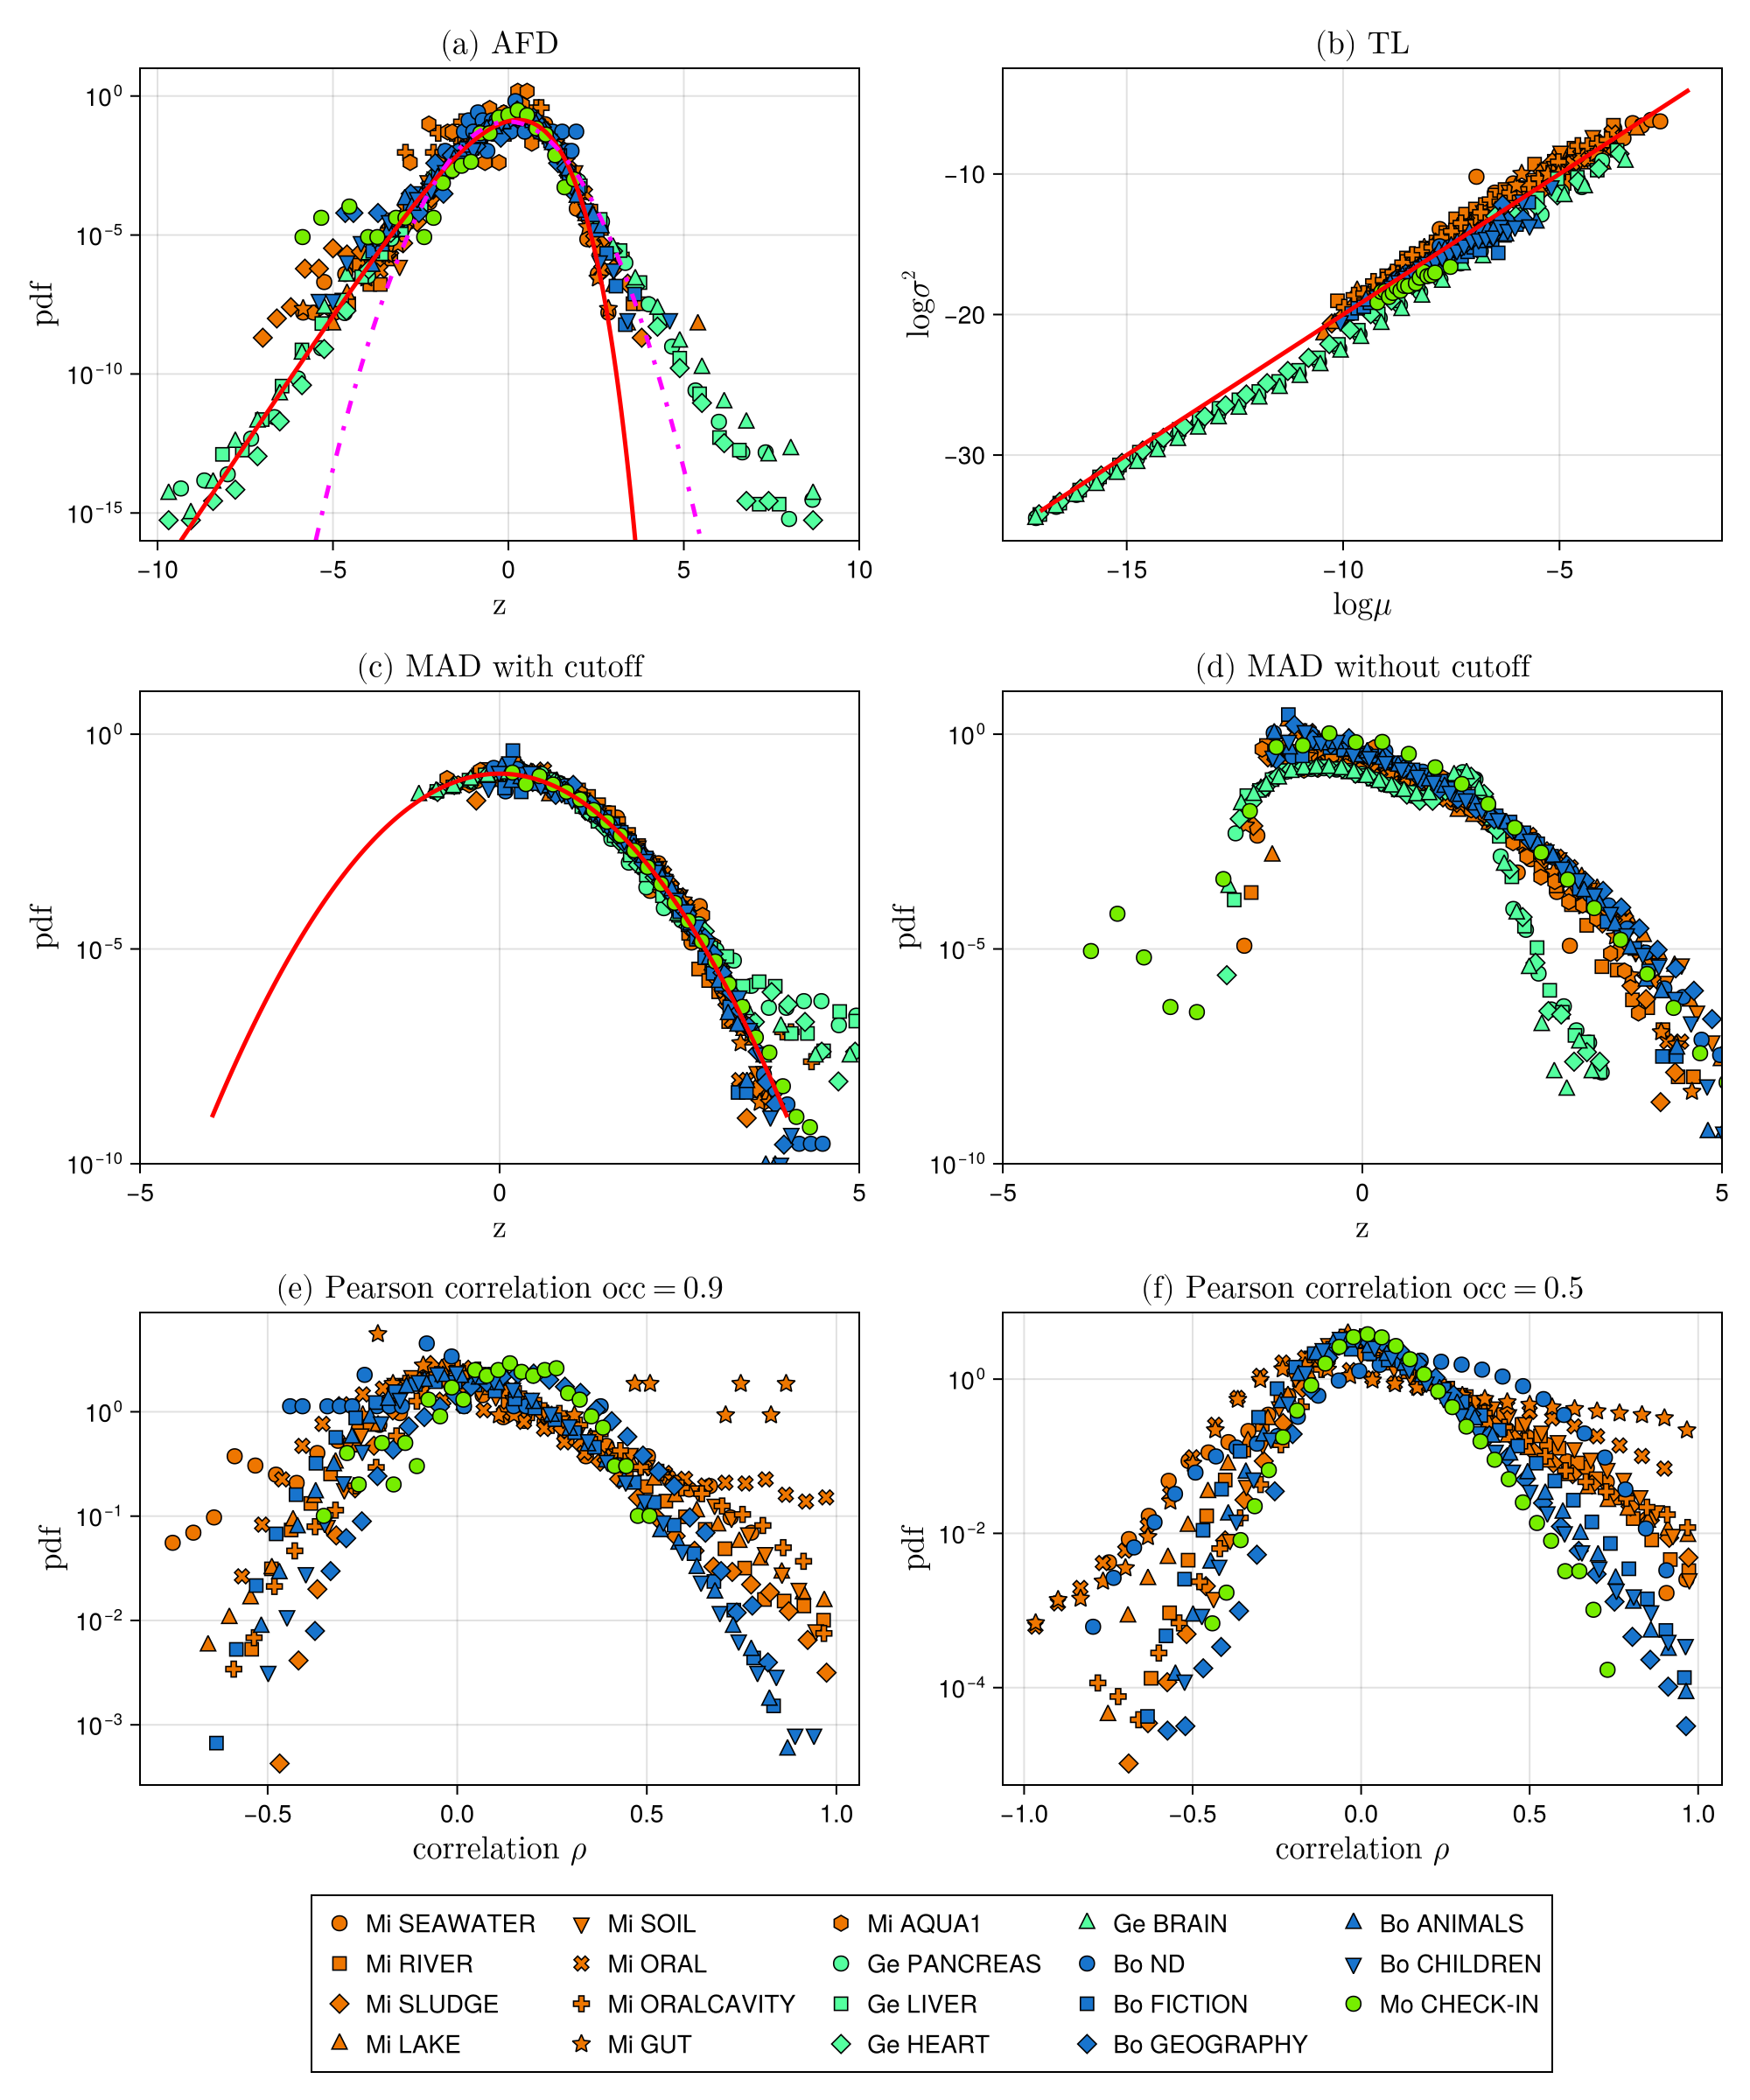

In [16]:
fig = Figure(
    size = (1000, 1200),
    rowsizes   = [Relative(0.85), Relative(0.15)],  # <-- two rows: 85% / 15%
    colsizes   = [Relative(0.8), Relative(0.2)],   # <-- two columns: 80% / 20%
    colgap     = 20,
    rowgap     = 0
)

ax1 = Axis(fig[1, 1]; yscale=log10, limits=((-10.5,10),(1e-16,1e1)),
            xlabel=L"\text{z}", ylabel=L"\text{pdf}", title=L"\text{(a) AFD}",
            xlabelsize=18, ylabelsize=18, titlesize=18)
ax2 = Axis(fig[1, 2]; xlabel=L"\log \mu", ylabel=L"\log \sigma^2", title=L"\text{(b) TL}",
            xlabelsize=18, ylabelsize=18, titlesize=18)
ax3 = Axis(fig[2, 1]; yscale=log10, limits=((-5,5),(1e-10,1e1)),
            xlabel=L"\text{z}", ylabel=L"\text{pdf}", title=L"\text{(c) MAD with cutoff}",
            xlabelsize=18, ylabelsize=18, titlesize=18)
ax4 = Axis(fig[2, 2]; yscale=log10, limits=((-5,5),(1e-10,1e1)),
            xlabel=L"\text{z}", ylabel=L"\text{pdf}", title=L"\text{(d) MAD without cutoff}",
            xlabelsize=18, ylabelsize=18, titlesize=18)
ax5 = Axis(fig[3, 1]; yscale=log10,
            xlabel=L"\text{correlation }\rho", ylabel=L"\text{pdf}", title=L"\text{(e) Pearson correlation occ=0.9}",
            xlabelsize=18, ylabelsize=18, titlesize=18)
ax6 = Axis(fig[3, 2]; yscale=log10,
            xlabel=L"\text{correlation }\rho", ylabel=L"\text{pdf}", title=L"\text{(f) Pearson correlation occ=0.5}",
            xlabelsize=18, ylabelsize=18, titlesize=18)

# markers, colors and labels to distinguish different datasets
shapes = (:circle, :rect, :diamond, :utriangle, 
          :dtriangle, :xcross, :cross, :star5, :hexagon)
colors = (:darkorange2, :seagreen1, :dodgerblue3, :chartreuse2)
env_labels = ["Mi", "Ge", "Bo", "Mo"];

# shared containers
all_plots   = Plot[]
all_labels  = String[]
seen_labels = Set{String}()

# --- AFD ---
for (j, afd) in enumerate(AFDs)
    for (i, key) in enumerate(keys(afd))
        x, y = afd[key]
        lbl = "$(env_labels[j]) $key"
        # decide if this one goes in the legend
        show_label = lbl ∉ seen_labels ? lbl : ""
        if lbl ∉ seen_labels
            push!(seen_labels, lbl)
            sc = scatter!(ax1, x, 10 .^ log.(y);
                          label=lbl,
                          color=colors[j], marker=shapes[i],
                          markersize=12, strokewidth=0.8, strokecolor=:black)
            push!(all_plots, sc)
            push!(all_labels, lbl)
        else
            scatter!(ax1, x, 10 .^ log.(y);
                     label="",
                     color=colors[j], marker=shapes[i],
                     markersize=12, strokewidth=0.8, strokecolor=:black)
        end
    end
end

zrange = -10:0.01:10
lines!(ax1, zrange, 10 .^ Utils.lrg(zrange, 3); color=:red, linewidth=2.5, linestyle=:solid)
lines!(ax1, zrange, 10 .^ Utils.lrln(zrange, 1); color=:magenta, linewidth=2.5, linestyle=:dashdot)

# --- TL ---
for (j, tl) in enumerate(TLs)
    for (i, key) in enumerate(keys(tl))
        x, y = tl[key]
        lbl = "$(env_labels[j]) $key"
        show_label = lbl ∉ seen_labels ? lbl : ""
        if lbl ∉ seen_labels
            push!(seen_labels, lbl)
            sc = scatter!(ax2, x, y;
                          label=lbl,
                          color=colors[j], marker=shapes[i],
                          markersize=12, strokewidth=0.8, strokecolor=:black)
            push!(all_plots, sc)
            push!(all_labels, lbl)
        else
            scatter!(ax2, x, y;
                     label="",
                     color=colors[j], marker=shapes[i],
                     markersize=12, strokewidth=0.8, strokecolor=:black)
        end
    end
end

xrange = -17:0.01:-2
lines!(ax2, xrange, 2 .* xrange; color=:red, linewidth=2.5, linestyle=:solid)

# --- MAD with cutoff ---
for (j, mad) in enumerate(MADs_c)
    for (i, key) in enumerate(keys(mad))
        x, y = mad[key]
        lbl = "$(env_labels[j]) $key"
        # decide if this one goes in the legend
        show_label = lbl ∉ seen_labels ? lbl : ""
        if lbl ∉ seen_labels
            push!(seen_labels, lbl)
            sc = scatter!(ax3, x, 10 .^ log.(y);
                          label=lbl,
                          color=colors[j], marker=shapes[i],
                          markersize=12, strokewidth=0.8, strokecolor=:black)
            push!(all_plots, sc)
            push!(all_labels, lbl)
        else
            scatter!(ax3, x, 10 .^ log.(y);
                     label="",
                     color=colors[j], marker=shapes[i],
                     markersize=12, strokewidth=0.8, strokecolor=:black)
        end
    end
end

xrange = -4:0.01:4
lines!(ax3, xrange, 10 .^ Utils.lrln(xrange, 1); color=:red, linewidth=2.5, linestyle=:solid)

# --- MAD without cutoff ---
for (j, mad) in enumerate(MADs)
    for (i, key) in enumerate(keys(mad))
        x, y = mad[key]
        lbl = "$(env_labels[j]) $key"
        # decide if this one goes in the legend
        show_label = lbl ∉ seen_labels ? lbl : ""
        if lbl ∉ seen_labels
            push!(seen_labels, lbl)
            sc = scatter!(ax4, x, 10 .^ log.(y);
                          label=lbl,
                          color=colors[j], marker=shapes[i],
                          markersize=12, strokewidth=0.8, strokecolor=:black)
            push!(all_plots, sc)
            push!(all_labels, lbl)
        else
            scatter!(ax4, x, 10 .^ log.(y);
                     label="",
                     color=colors[j], marker=shapes[i],
                     markersize=12, strokewidth=0.8, strokecolor=:black)
        end
    end
end

# --- Correlations occ = 0.9 ---
colors = (:darkorange2, :dodgerblue3, :chartreuse2, :white)
env_labels = ["Mi", "Bo", "Mo", "Null"];
for (j, corr) in enumerate(CORRs_9)
    for (i, key) in enumerate(keys(corr))
        x, y = corr[key]
        lbl = "$(env_labels[j]) $key"
        # decide if this one goes in the legend
        show_label = lbl ∉ seen_labels ? lbl : ""
        if lbl ∉ seen_labels
            push!(seen_labels, lbl)
            sc = scatter!(ax5, x, y;
                          label=lbl,
                          color=colors[j], marker=shapes[i],
                          markersize=12, strokewidth=0.8, strokecolor=:black)
            push!(all_plots, sc)
            push!(all_labels, lbl)
        else
            scatter!(ax5, x, y;
                     label="",
                     color=colors[j], marker=shapes[i],
                     markersize=12, strokewidth=0.8, strokecolor=:black)
        end
    end
end

# --- Correlations occ = 0.5 ---
for (j, corr) in enumerate(CORRs_5)
    for (i, key) in enumerate(keys(corr))
        x, y = corr[key]
        lbl = "$(env_labels[j]) $key"
        # decide if this one goes in the legend
        show_label = lbl ∉ seen_labels ? lbl : ""
        if lbl ∉ seen_labels
            push!(seen_labels, lbl)
            sc = scatter!(ax6, x, y;
                          label=lbl,
                          color=colors[j], marker=shapes[i],
                          markersize=12, strokewidth=0.8, strokecolor=:black)
            push!(all_plots, sc)
            push!(all_labels, lbl)
        else
            scatter!(ax6, x, y;
                     label="",
                     color=colors[j], marker=shapes[i],
                     markersize=12, strokewidth=0.8, strokecolor=:black)
        end
    end
end

# Legend
fig[4, 1:2] = Legend(fig, all_plots, all_labels;
    title       = "Data",
    orientation = :horizontal,
    nbanks      = 4,
    labelsize   = 14
)

fig


In [17]:
save("./Images/big_figure.pdf", fig)

CairoMakie.Screen{PDF}


# Reads distribution

In [6]:
# out = Utils.reads_distribution(NULL_MODEL; bins=30, plot=false, verbose=true, save=true, filename="./Data/reads_d/null");

In [27]:
@load "./Data/reads_d/microbiome.jld2" reads_out
microbiome_rd = deepcopy(reads_out)

@load "./Data/reads_d/genetic.jld2" reads_out
genetic_rd = deepcopy(reads_out)

@load "./Data/reads_d/books.jld2" reads_out
books_rd = deepcopy(reads_out)

@load "./Data/reads_d/mobility.jld2" reads_out
mobility_rd = deepcopy(reads_out)

@load "./Data/reads_d/null.jld2" reads_out
null_rd = deepcopy(reads_out)

reads_out = nothing
RDs = [microbiome_rd, genetic_rd, books_rd, mobility_rd];#, null_rd];

In [8]:
fig = Figure(size=(1100,500))
ax  = Axis(fig[1, 1];
        yscale=log10, limits=((-5,5),(1e-10,1e1)),
        xlabel = "z", ylabel = "pdf", 
        title = "Reads Distribution")

# markers and colors
shapes = (:circle, :rect, :diamond, :utriangle, 
          :dtriangle, :xcross, :cross, :star5, :hexagon)
colors = (:darkorange2, :seagreen1, :dodgerblue3, :chartreuse2, :white)

# Prepare separate lists for data and theory
data_plots   = Plot[]       # will hold scatter objects
data_labels  = String[]
env_labels = ["Mi", "Ge", "Bo", "Mo", "Null"]

for (j,rd) in enumerate(RDs)
    for (i,key) in enumerate(keys(rd))
        x, y = rd[key]
        sc = scatter!(ax, x, 10 .^ log.(y),
                    label=env_labels[j],
                    color=colors[j],
                    marker=shapes[i],
                    markersize=15,
                    strokewidth = 0.8,
                    strokecolor = :black)
        push!(data_plots, sc)
        push!(data_labels, "$(env_labels[j]) $key")
    end
end

zrange = -4:0.01:4
l3 = lines!(ax, zrange, 10 .^ Utils.lrln(zrange, 1); color=:red, linewidth=2.5, label="")
push!(data_plots, l3); push!(data_labels, "rescaled lognormal")

leg_data = Legend(fig, data_plots, data_labels;
    title        = "Data",
    orientation  = :vertical,
    nbanks = 2,
    # shrink the label and title fonts
    labelsize    = 12,
    titlesize    = 12,
)

fig[1, 2] = leg_data;

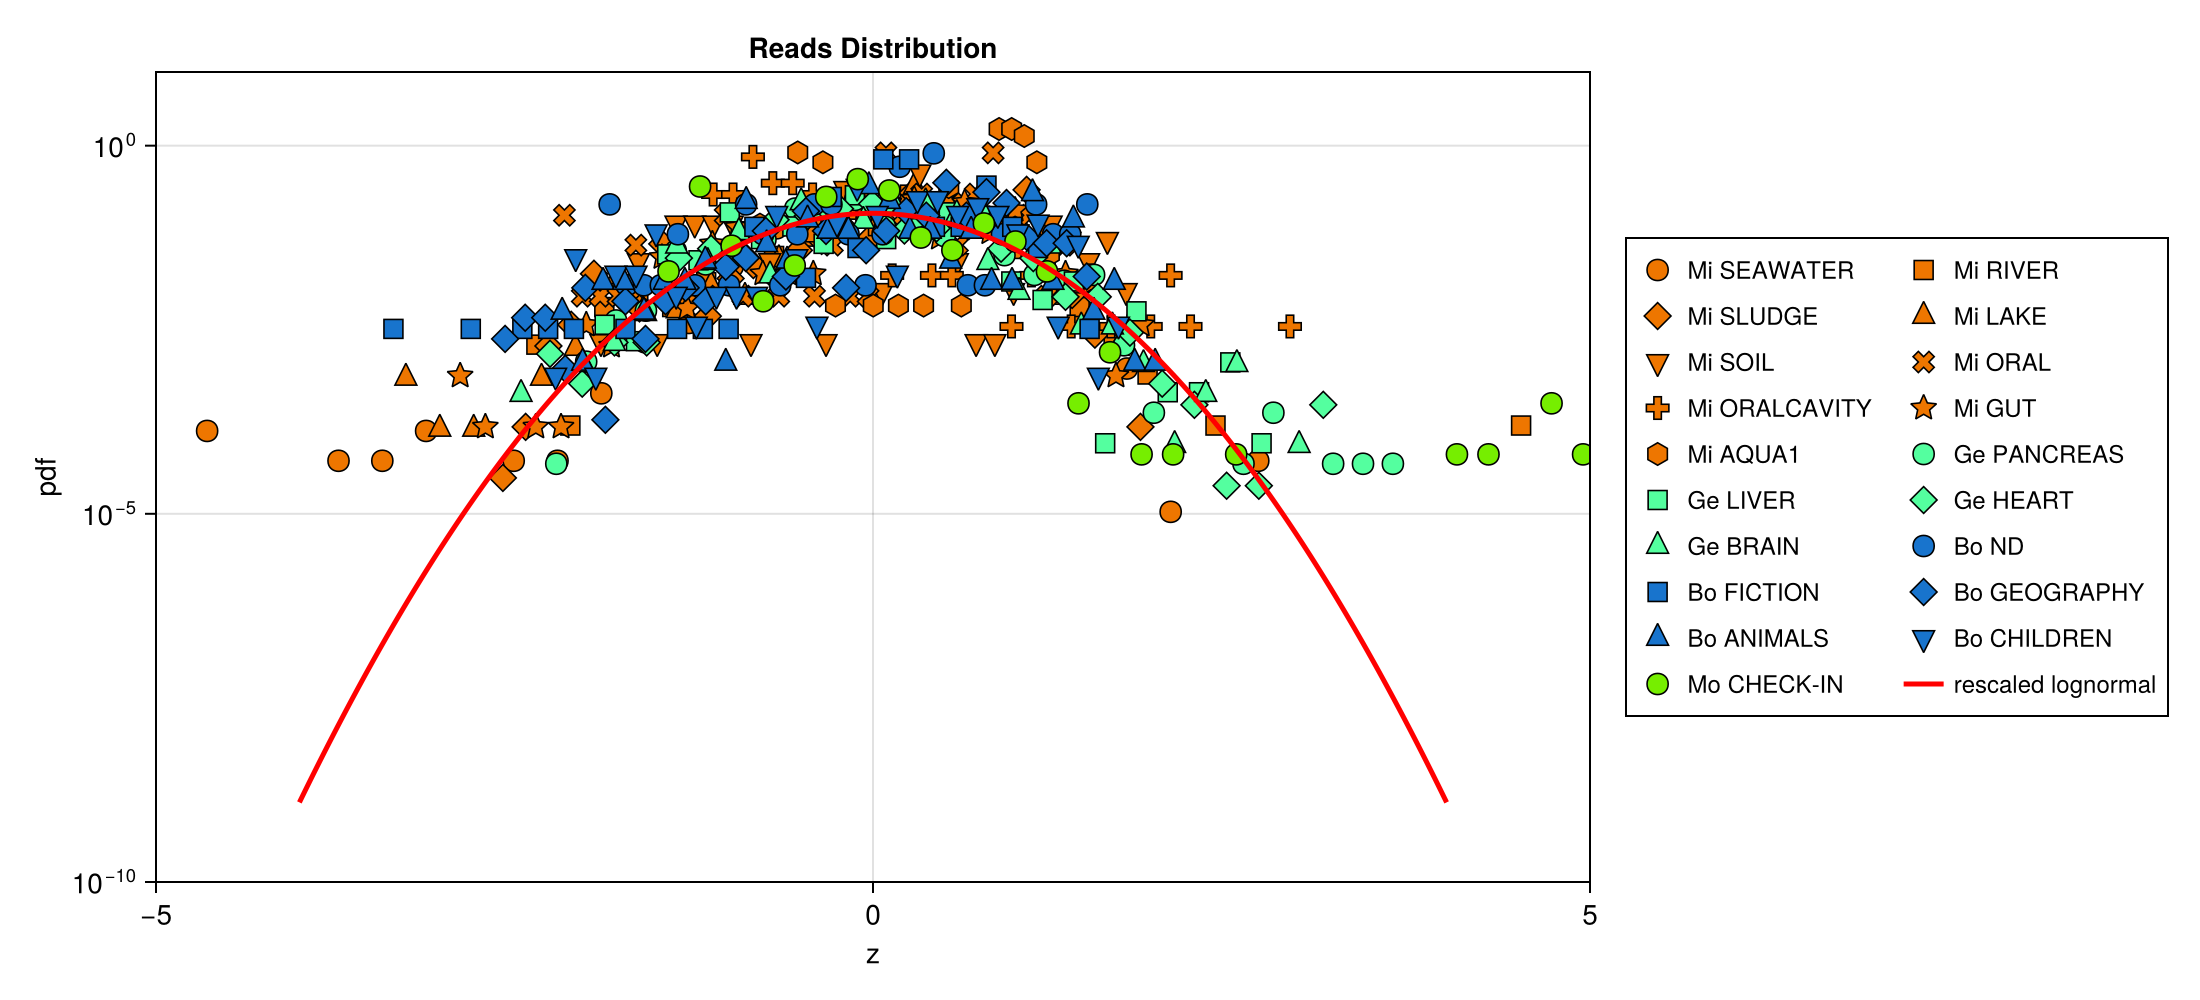

CairoMakie.Screen{IMAGE}


In [9]:
display(fig)

In [10]:
# save("./Images/read_distribution.png", fig)